# Final project pytorch

We will predict quality of wine based on its chemical properties using a neural network implemented in PyTorch. The dataset used is the ["Wine Quality" dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset). It will be a regression problem where we will predict the quality score of the wine.

## 1. Introduction to the dataset and problem statement

Input variables (based on physicochemical tests):\
1 - fixed acidity\
2 - volatile acidity\
3 - citric acid\
4 - residual sugar\
5 - chlorides\
6 - free sulfur dioxide\
7 - total sulfur dioxide\
8 - density\
9 - pH\
10 - sulphates\
11 - alcohol\
Output variable (based on sensory data):\
12 - quality (score between 0 and 10)

So we have 11 input features and 1 output feature (quality score).

## 2. Data loading, preprocessing, and exploration

In [575]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

import time

In [576]:
data = pd.read_csv('datasets/WineQT.csv')
print(data.shape)
data.head(5)

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [577]:
print(data.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [578]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [579]:
print(data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


We can drop the 'id' column as it does not provide useful information for prediction. There are not missing values in the dataset, so we can proceed without any imputation. All the variables are numerical, so we do not need to encode categorical variables. But we have to scale the features to ensure that they are on a similar scale, which can help improve the performance of the neural network.

In [580]:
data = data.drop(columns=['Id'])

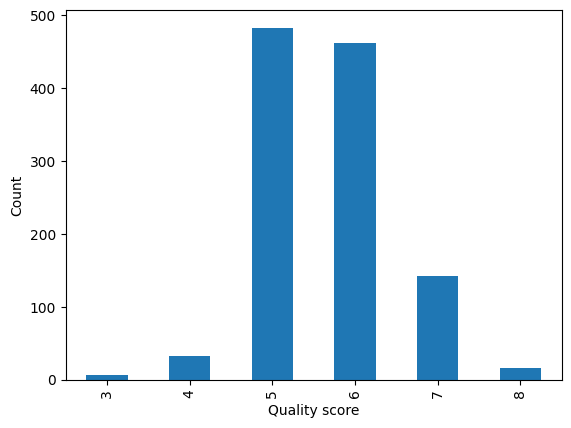

In [581]:
data["quality"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Quality score")
plt.ylabel("Count")
plt.show()


Although the quality scores are unevenly distributed, quality is treated as a continuous target variable and the task is framed as a regression problem.
> In regression the goal is to predict a continuous value, so the concept of class imbalance does not directly apply as it does in classification tasks. Our target is minimizing the difference between predicted and actual values across the entire range of possible outputs (e.g., using metrics like Mean Squared Error or Mean Absolute Error).

> In classification tasks, class imbalance refers to situations where certain classes have significantly more or fewer instances than others, which can lead to biased model performance.

In [582]:
y = data['quality'].copy()
X = data.drop(columns=['quality'])
print(X.shape, y.shape)

(1143, 11) (1143,)


In [583]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=True)

print(f"{X_train.shape=}, {y_train.shape=}")
print(f"{x_test.shape=}, {y_test.shape=}")

X_train.shape=(971, 11), y_train.shape=(971,)
x_test.shape=(172, 11), y_test.shape=(172,)


In [584]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
x_test = sc.transform(x_test)

In [585]:
x_train, x_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, shuffle=True)

print(f"{x_train.shape=}, {y_train.shape=}")
print(f"{x_val.shape=}, {y_val.shape=}")

x_train.shape=(776, 11), y_train.shape=(776,)
x_val.shape=(195, 11), y_val.shape=(195,)


## 3. Pytorch Dataset and DataLoader

In [586]:
class WineQualityDataset(torch.utils.data.Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32).unsqueeze(1)  # make it a column vector

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [587]:
train_dataset = WineQualityDataset(x_train, y_train)
val_dataset = WineQualityDataset(x_val, y_val)
test_dataset = WineQualityDataset(x_test, y_test)

In [588]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 4. Neural Network Model

- Input layer: 11 neurons (one for each feature)
- Hidden layers: 2 hidden layers with 64 neurons each and ReLU activation
- Output layer: 1 neuron (for regression output)

In [589]:
class WineQualityClassifier(nn.Module):
    def __init__(self):
        super(WineQualityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(11, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

> We don't need here a Sigmoid activation function in the output layer, as we are dealing with a regression problem and not a classification problem. The output will be a continuous value representing the quality score of the wine.

In [590]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [591]:
model = WineQualityClassifier().to(device)

In [592]:
for i_batch, (features, labels) in enumerate(train_loader):
    print(f"Batch {i_batch+1}:")
    print(f"  Features shape: {features.shape}")
    print(f"  Labels shape: {labels.shape}")
    break  # just show the first batch

outputs = model(features.to(device))
print(f"Model output shape: {outputs.shape}")

Batch 1:
  Features shape: torch.Size([128, 11])
  Labels shape: torch.Size([128, 1])
Model output shape: torch.Size([128, 1])


In [593]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [594]:
def train(model, device, train_dataloader, loss_fn, optimizer):
    model.train()  # set model to training mode

    epoch_loss = 0
    elements = 0

    for i_batch, (features, labels) in enumerate(train_dataloader):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()  # zero the gradients

        predictions = model(features)  # forward pass
        loss = loss_fn(predictions, labels.reshape(-1, 1))  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update weights

        # accumulate loss
        epoch_loss += loss.item()
        elements += labels.shape[0]

    # average loss over batches
    loss_train = epoch_loss / (i_batch + 1)  # note +1 to avoid zero index issue

    return loss_train


In [595]:
def evaluation(model, device, val_dataloader, loss_fn):
    model.eval()  # set model to evaluation mode

    # Initalize variables for the metrics
    epoch_loss = 0

    # we don't need gradients for validation, we just do forward pass
    with torch.no_grad():  # disable gradient computation
        for i_batch, (features, labels) in enumerate(val_dataloader):
            features, labels = features.to(device), labels.to(device)

            predictions = model(features)  # forward pass

            loss = loss_fn(predictions, labels.reshape(-1, 1))  # compute loss

            # save metrics
            epoch_loss += loss.item()

    # Calculate average loss and accuracy for the epoch
    loss_val = epoch_loss / i_batch

    return loss_val

In [596]:
def training_evaluation_loop(epochs, model, device, train_dataloader, val_dataloader, loss_fn, optimizer):
    train_losses = []
    val_losses = []
    total_time = 0

    for epoch in range(epochs):
        start_time = time.time()

        loss_train = train(model, device, train_dataloader, loss_fn, optimizer)
        loss_val = evaluation(model, device, val_dataloader, loss_fn)

        train_losses.append(loss_train)
        val_losses.append(loss_val)

        end_time = time.time()
        epoch_duration = end_time - start_time
        total_time += epoch_duration

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {loss_train:.4f} - "
              f"Val Loss: {loss_val:.4f} - "
              f"Time: {epoch_duration:.2f}s")
        
    print(f"Total training time: {total_time:.2f}s")

    return train_losses, val_losses

## 5. Training the model and evaluation

In [597]:
epochs = 400

train_losses, val_losses = training_evaluation_loop(
    epochs, model, device, train_loader, val_loader, loss_fn, optimizer
)

Epoch 1/400 - Train Loss: 32.9627 - Val Loss: 65.7711 - Time: 0.02s
Epoch 2/400 - Train Loss: 31.4844 - Val Loss: 63.0274 - Time: 0.01s
Epoch 3/400 - Train Loss: 30.0187 - Val Loss: 60.3875 - Time: 0.01s
Epoch 4/400 - Train Loss: 27.7062 - Val Loss: 57.8806 - Time: 0.01s
Epoch 5/400 - Train Loss: 26.8239 - Val Loss: 55.4131 - Time: 0.01s
Epoch 6/400 - Train Loss: 26.5271 - Val Loss: 52.9139 - Time: 0.00s
Epoch 7/400 - Train Loss: 24.6384 - Val Loss: 50.4242 - Time: 0.00s


Epoch 8/400 - Train Loss: 24.0084 - Val Loss: 47.8977 - Time: 0.00s
Epoch 9/400 - Train Loss: 22.3362 - Val Loss: 45.3375 - Time: 0.00s
Epoch 10/400 - Train Loss: 21.5624 - Val Loss: 42.7052 - Time: 0.01s
Epoch 11/400 - Train Loss: 19.5506 - Val Loss: 40.0289 - Time: 0.00s
Epoch 12/400 - Train Loss: 18.6183 - Val Loss: 37.2832 - Time: 0.01s
Epoch 13/400 - Train Loss: 17.6006 - Val Loss: 34.4520 - Time: 0.00s
Epoch 14/400 - Train Loss: 16.2450 - Val Loss: 31.5370 - Time: 0.00s
Epoch 15/400 - Train Loss: 14.2063 - Val Loss: 28.6573 - Time: 0.00s
Epoch 16/400 - Train Loss: 13.0860 - Val Loss: 25.7142 - Time: 0.00s
Epoch 17/400 - Train Loss: 11.3837 - Val Loss: 22.8422 - Time: 0.00s
Epoch 18/400 - Train Loss: 10.2290 - Val Loss: 20.0303 - Time: 0.00s
Epoch 19/400 - Train Loss: 8.6124 - Val Loss: 17.3840 - Time: 0.00s
Epoch 20/400 - Train Loss: 7.3960 - Val Loss: 14.9104 - Time: 0.00s
Epoch 21/400 - Train Loss: 6.3119 - Val Loss: 12.6409 - Time: 0.00s
Epoch 22/400 - Train Loss: 5.2881 - Val

## 6. Model evaluation and metrics

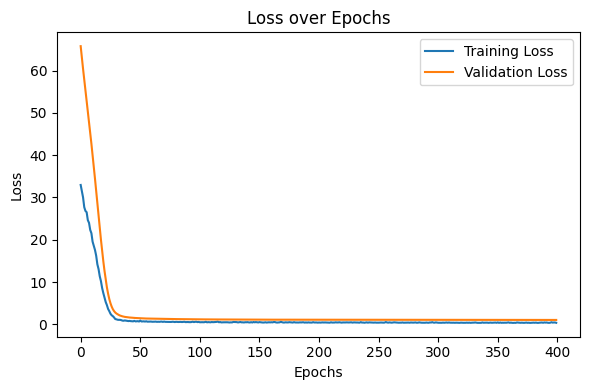

In [598]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

# Loss
axes.plot(range(epochs), train_losses, label='Training Loss')
axes.plot(range(epochs), val_losses, label='Validation Loss')
axes.set_xlabel('Epochs')
axes.set_ylabel('Loss')
axes.set_title('Loss over Epochs')
axes.legend()

plt.tight_layout()
plt.show()


In [599]:
from sklearn.metrics import mean_squared_error

def predictions(model, test_dataloader, device):
    predictions = []
    true_labels = []

    model.eval()  # set model to evaluation mode
    with torch.no_grad():  # disable gradient computation
        for features, labels in test_dataloader:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)  # forward pass

            # we detach from the computation graph and move to CPU for numpy conversion
            # numpy() requires the tensor to be on CPU and converts to numpy array
            predictions.append(outputs.detach().cpu().numpy())
            true_labels.append(labels.detach().cpu().numpy())

        predictions = np.vstack(predictions)
        true_labels = np.vstack(true_labels)
        mse = mean_squared_error(true_labels, predictions)
        print(f'Test set MSE: {mse:.4f}')

    return predictions, true_labels

In [600]:
predicted, real_values = predictions(model, test_loader, device)

preds_df = pd.DataFrame({
    'real_values': np.hstack(real_values),
    'predictions': np.hstack(predicted)
})

preds_df['error'] = np.abs(preds_df.real_values - preds_df.predictions)

Test set MSE: 0.4559


MSE 0.4559 is not too bad, but we can try to improve it by tuning the hyperparameters, such as learning rate, number of epochs, batch size, and network architecture.

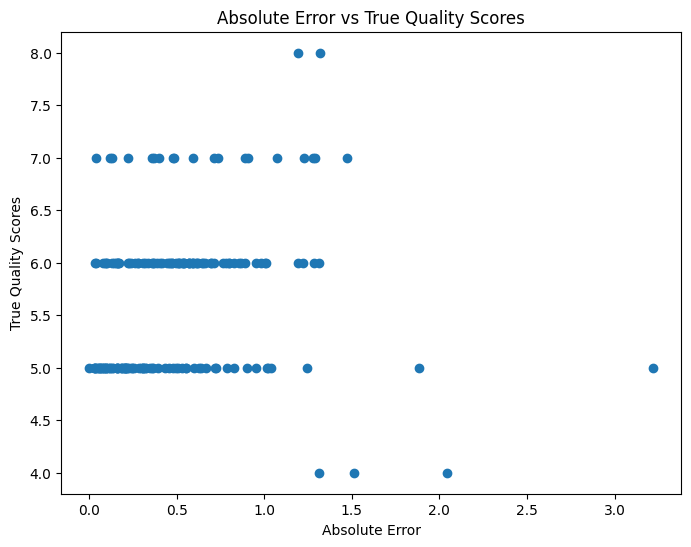

In [601]:
plt.figure(figsize=(8, 6))
plt.scatter(preds_df.error, preds_df.real_values)
plt.xlabel('Absolute Error')
plt.ylabel('True Quality Scores')
plt.title('Absolute Error vs True Quality Scores')
plt.show()

The dataset has predicted quality scores 5, 6, 7 better than other quality scores, which is expected as these are the most frequent quality scores in the dataset. 1, 2, 9 quality scores are not presented in the test set, so the model cannot predict them.